<a href="https://colab.research.google.com/github/CarlosBaztan/Clases-Python-UNIR/blob/main/Clase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##For vs While



*   ***For*** --> cuando sabemos cuantas veces se repite un proceso
*  ***While*** --> cuando queremos que el program se repita mientras se cumpla una condición

##Bucle While


In [12]:
#Pedir al usuario si quiere usar el simulador
continuar = input ("¿Quieres iniciar el simulador de clientes? (S/N): ").upper() #Si pone s o n, se ponga S o N automaticamente

#Validacion inicial
while continuar not in ('S', 'N'): #Si lo que escribe no es ni S ni N
  continuar= input("Por favor, responde solo S o N: ").upper

while continuar == "S": #Si hemos contestado S en el prumer input, entramos por este punto
  gasto_mensual=float(input("Introduce el gasto mensual promedio del cliente: "))
  print(f"El gasto anual proyectado de este cliente es: {gasto_mensual*12} euros")
  continuar = input ("¿Quiere calcular el gasto de otro cliente? (S/N): ").upper()

  print("Saliendo del simulador.")

KeyboardInterrupt: Interrupted by user

##Append y len

In [ ]:
#Paises donde operamos ahora --> len()
paises_operacion = ["Australia", "Estados Unidos", "Canada"]
print(f"El nombre de los países donde operamos son: {paises_operacion}")
print(f"El número de países donde operamos es: {len(paises_operacion)}")

#Añadimos un nuevo país donde operamos --> .append
paises_operacion.append("España")
print(f"El nombre de los países donde operamos son: {paises_operacion}")
print(f"El número de países donde operamos son: {len(paises_operacion)}")

##Limpiar datos sucios

In [ ]:
import pandas as pd
import numpy as np

#Simular cargar un dataframe. Para ello, definimos un diccionario y luego lo pasamos a dataframe
datos_sucios= {
    "Region.": ["Australia", "Estado Unidos", "Canada", "Alemania"],
    "Salario anual": ["81926", "81076", "", "51804"], #Son números que están en formato texto, y un dato nulo
    "Gasto medio": ["50,97", "32,11", "54,08", "N/A"] #Están en tipo texto y además hay un N/A
}
df_clientes = pd.DataFrame(datos_sucios)
df_clientes

,Region.,Salario anual,Gasto medio
0,Australia,81926,"50,97"
1,Estado Unidos,81076,"32,11"
2,Canada,,"54,08"
3,Alemania,51804,N/A


In [ ]:
#Ver cuantas filas tiene
len(df_clientes)
#Ver cuantas filas y columnas
df_clientes.shape
#Nombre de las columnas
df_clientes.columns
#Tipos de datos que tenemos
df_clientes.dtypes

,0
Region.,object
Salario anual,object
Gasto medio,object


In [ ]:
#Transformamos variables tipo texto en número
variables_numericas = ["Salario anual", "Gasto medio"]

for col in variables_numericas: #Creamos variable temporal col que recorre la lista de variables numericas
  #Nos quitamos las comas
  df_clientes[col] = df_clientes[col].astype(str).str.replace(",", ".")
  df_clientes[col] = pd.to_numeric(df_clientes[col], errors="coerce") #Coerce lo usamos para procesar el N/A

print(df_clientes.dtypes)

Region.           object
Salario anual    float64
Gasto medio      float64
dtype: object


In [11]:
#Cómo identificar el número de valores nulos
df_clientes.info() #Cuántos no nulos hay
df_clientes.isnull().sum() #Cuántos nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Region.        4 non-null      object 
 1   Salario anual  3 non-null      float64
 2   Gasto medio    3 non-null      float64
dtypes: float64(2), object(1)
memory usage: 228.0+ bytes


,0
Region.,0
Salario anual,1
Gasto medio,1


#Group by

In [13]:
#Cargar el dataset
df = pd.read_excel("AWcustomersandsales.xlsx")
df


,CustomerID,Title,FirstName,MiddleName,LastName,Suffix,AddressLine1,AddressLine2,City,StateProvinceName,...,MaritalStatus,HomeOwnerFlag,NumberCarsOwned,NumberChildrenAtHome,TotalChildren,YearlyIncome,LastUpdated,BikeBuyer,AvgMonthSpend,BikeBuyerText
0,21173,NaN,Chad,C,Yuan,NaN,7090 C. Mount Hood,NaN,Wollongong,New South Wales,...,M,1,3,0,1,81916,2017-03-06,1,50.97,YES
1,13249,NaN,Ryan,NaN,Perry,NaN,3651 Willow Lake Rd,NaN,Shawnee,British Columbia,...,M,1,2,1,2,81076,2017-03-06,1,53.11,YES
2,29350,NaN,Julia,NaN,Thompson,NaN,1774 Tice Valley Blvd.,NaN,West Covina,California,...,S,0,3,0,0,86387,2017-03-06,1,54.08,YES
3,13503,NaN,Theodore,NaN,Gomez,NaN,2103 Baldwin Dr,NaN,Liverpool,England,...,M,1,2,1,2,61481,2017-03-06,1,56.93,YES
4,22803,NaN,Marshall,J,Shan,NaN,Am Gallberg 234,NaN,Werne,Nordrhein-Westfalen,...,S,1,1,0,0,51804,2017-03-06,1,55.41,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18350,25414,NaN,Grace,C,Bailey,NaN,6627 Camelback Ct.,NaN,Coronado,California,...,M,0,1,0,2,52953,2017-03-06,0,48.14,NO
18351,11459,NaN,Tasha,NaN,Deng,NaN,9627 Kendall Rd,NaN,Port Macquarie,New South Wales,...,S,0,2,0,0,60992,2017-03-06,1,50.23,YES
18352,12160,NaN,Jaclyn,NaN,Zhang,NaN,4364 Viera Avenue,NaN,Beaverton,Oregon,...,S,0,2,0,0,51859,2017-03-06,1,49.56,YES
18353,14353,NaN,Erin,I,Reed,NaN,3866 Mt. Everest Court,NaN,Vancouver,British Columbia,...,S,0,0,0,0,87177,2017-03-06,0,51.42,NO


In [14]:
#Agrupar por país (CountryRegionName) y calcular la media del gasto mensual ("AvgMonthSpend")

gasto_mensual_por_pais= df.groupby("CountryRegionName")[["AvgMonthSpend", "YearlyIncome"]].mean()
gasto_mensual_por_pais

,AvgMonthSpend,YearlyIncome
CountryRegionName,,
Australia,51.729305,73685.008128
Canada,51.572873,72004.467866
France,51.528897,66694.525348
Germany,51.703356,69584.657046
United Kingdom,51.730657,71978.491329
United States,51.902123,74799.850116


In [15]:
#Para el cálculo de diferentes estadísticos
tabla_resumen = df.groupby("CountryRegionName").agg({
    "YearlyIncome": ["max", "min", "mean", "std"],
    "AvgMonthSpend": ["sum", "mean"]
})
tabla_resumen

YearlyIncome                                     \
                           max    min          mean           std   
CountryRegionName                                                   
Australia               139018  25449  73685.008128  30719.211078   
Canada                  138805  25435  72004.467866  31169.709670   
France                  138920  25545  66694.525348  28370.918847   
Germany                 139082  25445  69584.657046  29691.010387   
United Kingdom          138898  25469  71978.491329  30246.319248   
United States           139115  25492  74799.850116  31172.821683   

                  AvgMonthSpend             
                            sum       mean  
CountryRegionName                           
Australia             184570.16  51.729305  
Canada                 80247.39  51.572873  
France                 92494.37  51.528897  
Germany                91359.83  51.703356  
United Kingdom         98443.44  51.730657  
United States         403071.89  51.902123

#Gráficos

In [16]:
#Agrupamos para tener el gasto medio por Ocupación
gasto_por_ocupación = df.groupby("Occupation")["AvgMonthSpend"].mean()
gasto_por_ocupación

,AvgMonthSpend
Occupation,
Clerical,52.745712
Management,53.706977
Manual,48.600326
Professional,54.559083
Skilled Manual,51.157083


In [19]:
#Para hacer gráficos horizontales, ordenamos de menor a mayor
top_ocupaciones = gasto_por_ocupación.sort_values(ascending=True)
top_ocupaciones

,AvgMonthSpend
Occupation,
Manual,48.600326
Skilled Manual,51.157083
Clerical,52.745712
Management,53.706977
Professional,54.559083


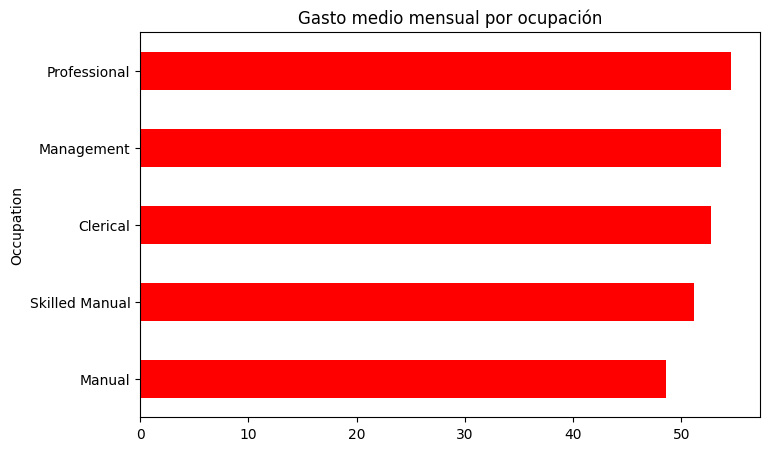

In [20]:
#Pedimos que la tabla se dibuje. Usamos "barh" para barras horizontales
grafico= top_ocupaciones.plot.barh(
    title="Gasto medio mensual por ocupación",
    color="red",
    figsize=(8,5)
)

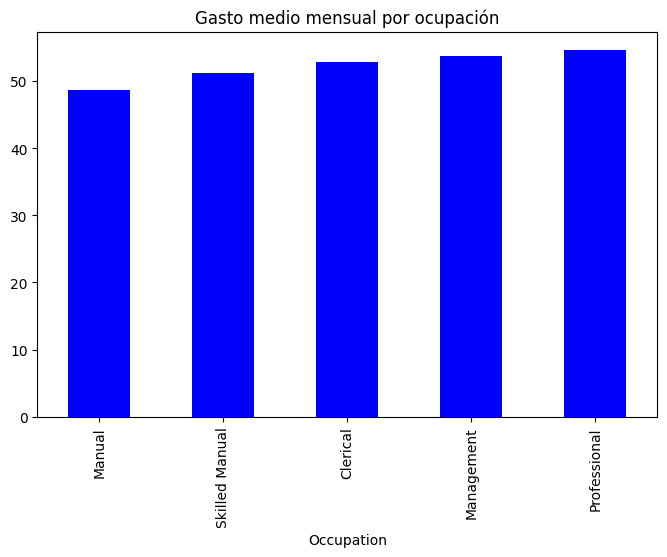

In [21]:
#Pedimos que la tabla se dibuje. Usamos "bar" para barras verticales
grafico= top_ocupaciones.plot.bar(
    title="Gasto medio mensual por ocupación",
    color="blue",
    figsize=(8,5)
)

In [ ]:
#Mejor gráficos horizonates cuando tenemos muchas categorías

In [22]:
#Contar cuantos clientes tenemos por país (value_counts())
clientes_por_pais = df["CountryRegionName"].value_counts()
clientes_por_pais

,count
CountryRegionName,
United States,7766
Australia,3568
United Kingdom,1903
France,1795
Germany,1767
Canada,1556


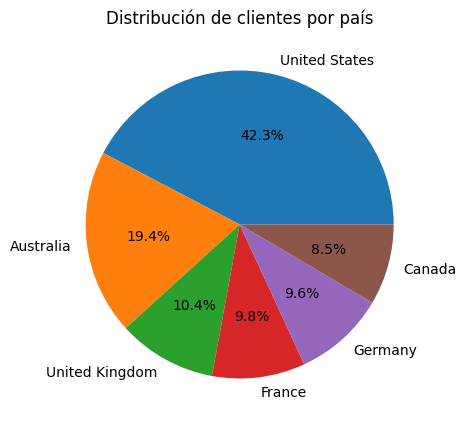

In [24]:
grafico_tarta = clientes_por_pais.plot.pie(
    title="Distribución de clientes por país",
    figsize=(8,5),
    autopct= "%1.1f%%", #Nos da el porcentaje de cada país
    ylabel="" #Quitar el índice de eje y
)